In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [9]:
##load datasets 
iris = load_iris()
#print(iris)
##features and target
x = iris.data
y = iris.target

###feature name
print("feature name = ",iris.feature_names)
print("target classes = ",iris.target_names)



feature name =  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target classes =  ['setosa' 'versicolor' 'virginica']


In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print("training data :",x_train.shape)
print("testing data :" ,x_test.shape)

training data : (120, 4)
testing data : (30, 4)


In [18]:
###create a random forest model###
rf_model = RandomForestClassifier(
    n_estimators=100,#number of tree
    criterion="gini", ##split quality
    random_state=42
)

##train model
rf_model.fit(x_train,y_train)
    
    

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
### make predictions##
y_pred = rf_model.predict(x_test)
print("predictions",y_pred[:10])
print("actual",y_test[:10])

predictions [2 2 0 0 2 1 0 2 1 2]
actual [2 2 0 0 2 1 0 2 2 1]


In [23]:
##evaluate the model
##accuracy
accuracy = accuracy_score(y_test,y_pred)
print("accuracy =",accuracy)

##classification report ##
print("classification report =\n",classification_report(y_test,y_pred))

##confusion matrix#3
print("confusion matrix =\n",confusion_matrix(y_test,y_pred))

accuracy = 0.9
classification report =
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      0.75      0.80         8
           2       0.85      0.92      0.88        12

    accuracy                           0.90        30
   macro avg       0.90      0.89      0.89        30
weighted avg       0.90      0.90      0.90        30

confusion matrix =
 [[10  0  0]
 [ 0  6  2]
 [ 0  1 11]]


             feature  Importance
2  petal length (cm)    0.479559
3   petal width (cm)    0.396605
0  sepal length (cm)    0.105478
1   sepal width (cm)    0.018357


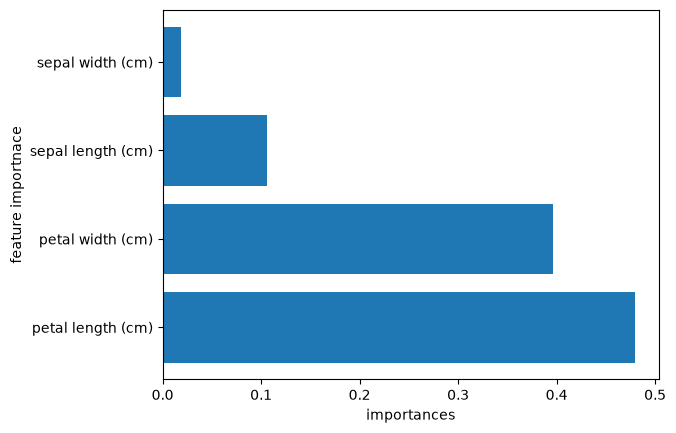

In [30]:
##feature importance#3
import matplotlib.pyplot as plt 
importances = rf_model.feature_importances_
features = iris.feature_names

##create dataframe
feature_df = pd.DataFrame({
    "feature":features,
    "Importance":importances,
}).sort_values(by="Importance",ascending=False)
print(feature_df)

plt.barh(feature_df["feature"],feature_df["Importance"])
plt.xlabel("importances")
plt.ylabel("feature importnace")
plt.show()
